# Nb to explore visual HB activity estimation

In [ ]:
import sys, cv2
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a wide width for display
pd.set_option('display.colheader_justify', 'center')  # Align column headers
sys.path.append('RHCVisualisation/RHCImaging')
from RHCVisualisation.RHCImaging.libimage import fetchImagesPaths
from RHCVisualisation.RHCImaging.VideoManagment.videolib import initVideoWriter
import matplotlib.pyplot as plt
from libActivity import computeRpiActivities

## Congfiguration

In [2]:
hive_nb = 1
exp = 'SharpDay'

rootpath_imgs = '/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11-25.01_metabolism_OH/Images/'
img_freq = "1min" # Sampling frequency of images
start_ts = pd.Timestamp("2024-12-16 12:00:00").tz_localize('UTC')
time_window = pd.Timedelta("45 minutes")
threshold = 25

verbose = False

## Main code

In [3]:
print(f"Will gather images between {start_ts} and {start_ts + time_window} every {img_freq}.")
all_ts = pd.date_range(start=start_ts, end=start_ts + time_window, freq=img_freq)
imgs_paths = fetchImagesPaths(rootpath_imgs, all_ts, hive_nb, verbose=verbose)
print(imgs_paths.head())

Will gather images between 2024-12-16 12:00:00+00:00 and 2024-12-16 12:45:00+00:00 every 1min.
                                                 h1r1                                               h1r2                                               h1r3                                               h1r4                       
2024-12-16 12:00:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-12-16 12:01:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-12-16 12:02:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudSt

In [4]:
activities, diff_hives = computeRpiActivities(imgs_paths, threshold=threshold, verbose=verbose)

### Compute activity metric

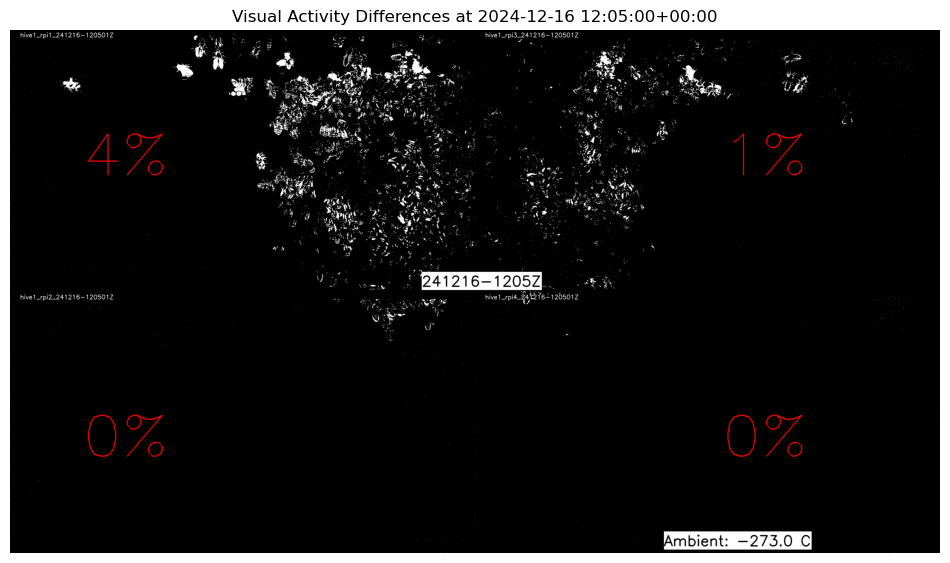

In [5]:
def generateAnnotatedSnapshots(index:int):
    snapshot = diff_hives[index].snapshot()
    _activities = activities[index]

    # Convert snapshot to RGB
    snapshot_rgb = cv2.cvtColor(snapshot, cv2.COLOR_BGR2RGB)
    # Annotate the snapshot with activity values : value 0 at the top left, value 1 at the bottom left, value 2 at the top right, value 3 at the bottom right
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 8
    font_color = (255, 0, 0)  # Red color
    thickness = 3
    cv2.putText(snapshot_rgb, f"{int(_activities.activity_values[0]*100)}%", (300, 600), font, font_scale, font_color, thickness)
    cv2.putText(snapshot_rgb, f"{int(_activities.activity_values[1]*100)}%", (300, snapshot_rgb.shape[0] - 400), font, font_scale, font_color, thickness)
    cv2.putText(snapshot_rgb, f"{int(_activities.activity_values[2]*100)}%", (snapshot_rgb.shape[1] - 900, 600), font, font_scale, font_color, thickness)
    cv2.putText(snapshot_rgb, f"{int(_activities.activity_values[3]*100)}%", (snapshot_rgb.shape[1] - 900, snapshot_rgb.shape[0] - 400), font, font_scale, font_color, thickness)
    return snapshot_rgb

index = 5  # Change index to visualize different time points
snapshot_rgb = generateAnnotatedSnapshots(index)

plt.figure(figsize=(12, 8))
plt.imshow(snapshot_rgb)
plt.axis('off')
plt.title(f"Visual Activity Differences at {diff_hives[index].ts}")
plt.show()

### Save video

In [6]:
dest = 'outputVideos'
filename = f'hive{hive_nb}_{threshold}_{start_ts.strftime("%Y%m%d_%H%M")}_{(start_ts + time_window).strftime("%Y%m%d_%H%M")}'
video = initVideoWriter(dest, shape=diff_hives[1].snapshot().shape, name=filename, fps=15) # RGB video
for idx in range(1, len(diff_hives)):
    snapshot_rgb = generateAnnotatedSnapshots(idx)
    video.write(cv2.cvtColor(snapshot_rgb, cv2.COLOR_RGB2BGR))  # Convert back to BGR for video writing

video.release()